# Évaluation des Modèles

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root + '/src')

from evaluation.evaluator import TimeSeriesEvaluator
from models.baselines import \
    AverageRegressor, LastWeekPersistenceRegressor, YesterdayPersistenceRegressor, LinearRegressor, SimilarDayRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

In [2]:
evaluator = TimeSeriesEvaluator(df)

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start)

Découpage Temporel
Train: 70127 lignes (74.4%)
Val: 8784 lignes (9.3%)
Test: 15313 lignes (16.3%)



### 3. La Vraie Évaluation : Rolling Walk-Forward


In [3]:
average_model = AverageRegressor()
evaluator.rolling_validation(average_model, df_train, df_val, freq="1D")
week_model = LastWeekPersistenceRegressor()
evaluator.rolling_validation(week_model, df_train, df_val, freq="1D")
yesterday_model = YesterdayPersistenceRegressor()
evaluator.rolling_validation(yesterday_model, df_train, df_val, freq="1D")
similar_model = SimilarDayRegressor(k=4, temp_weight=0.5)
evaluator.rolling_validation(similar_model, df_train, df_val, freq="1D")
# lr_model = LinearRegressor(
# 	features_cols=[
# 		'consommation_mw_meme_heure_derniere_connue',
#         'consommation_mw_derniere_connue',
# 		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
# 		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
# 		'temperature_c_pondere_pop_meme_heure_derniere_connue',
# 		'temperature_c_pondere_pop_derniere_connue',
# 		'temperature_c_pondere_pop_moins_7', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
# 	]
# )
# evaluator.rolling_validation(lr_model, df_train, df_val, freq="1D")

Évaluation de AverageRegressor | 8784 lignes | réentraînement/1D | 366 itérations
Progression: 2024-12-31 00:00...

Score : MAE = 8528.81 MW | RMSE = 10311.97 MW | MAPE = 18.36%

Évaluation de LastWeekPersistenceRegressor | 8784 lignes | réentraînement/1D | 366 itérations
Progression: 2024-12-31 00:00...

Score : MAE = 3229.23 MW | RMSE = 4845.62 MW | MAPE = 6.05%

Évaluation de YesterdayPersistenceRegressor | 8784 lignes | réentraînement/1D | 366 itérations
Progression: 2024-12-31 00:00...

Score : MAE = 3182.98 MW | RMSE = 4362.14 MW | MAPE = 6.40%

Évaluation de SimilarDayRegressor | 8784 lignes | réentraînement/1D | 366 itérations
Progression: 2024-12-31 00:00...

Score : MAE = 3413.45 MW | RMSE = 5526.34 MW | MAPE = 6.39%



{'MAE': 3413.4470912942315,
 'RMSE': 5526.3350712955635,
 'MAPE': np.float64(6.389790843380001)}

### 4. Visualisation

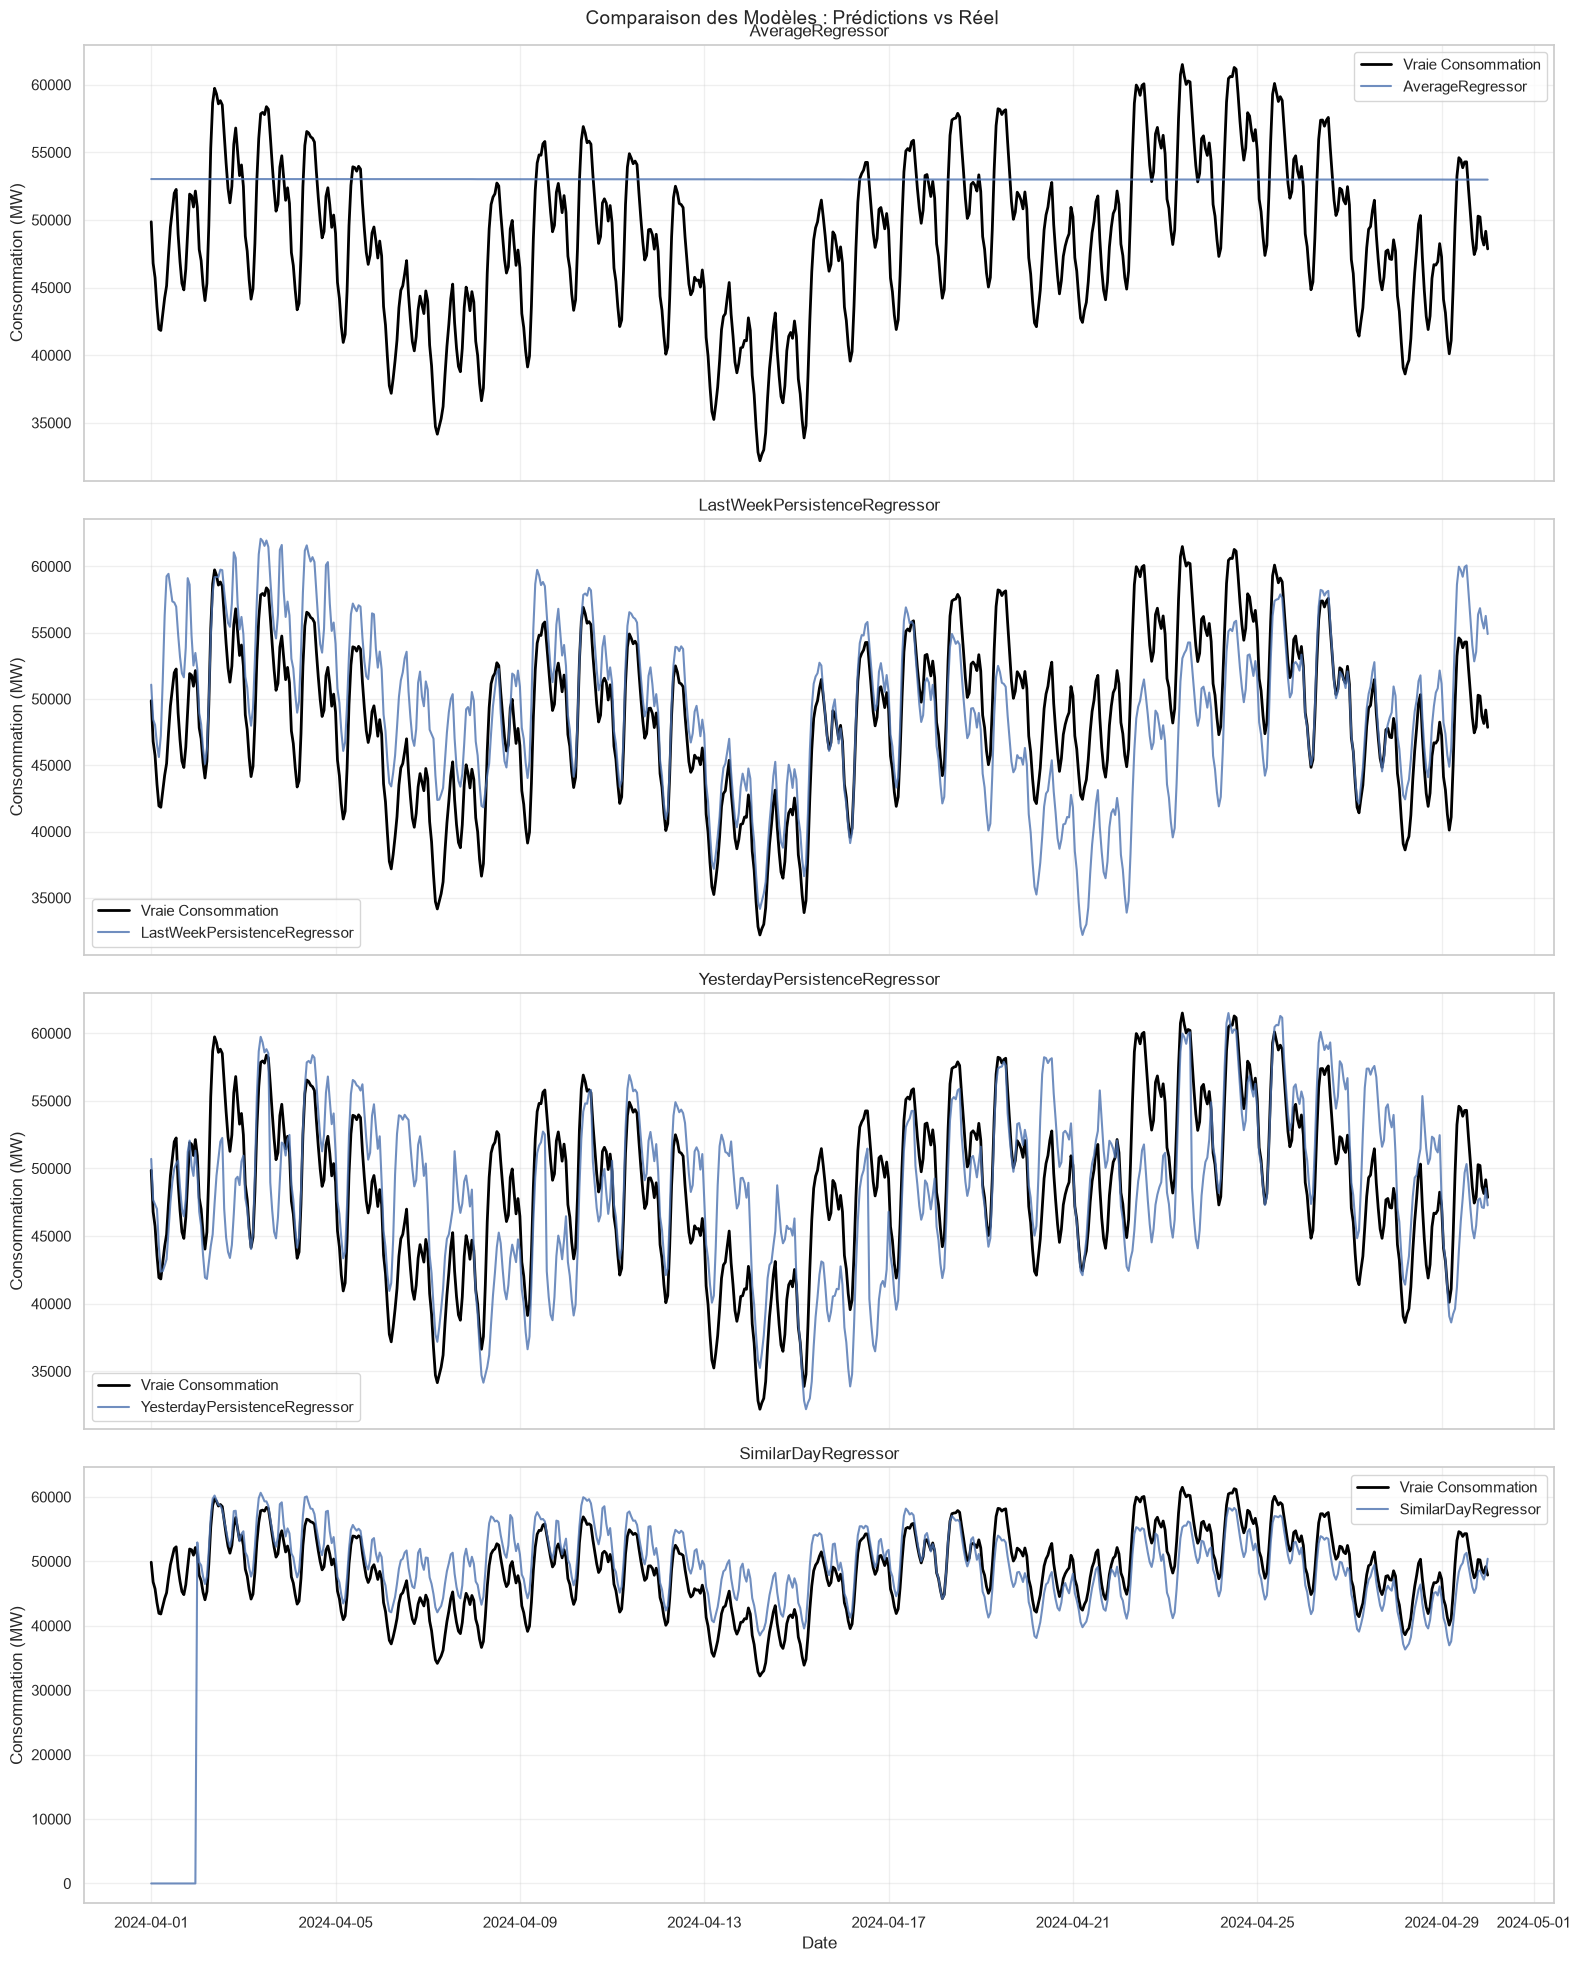

In [4]:
# Zoomons sur le mois de Avril 2024
start_zoom = pd.to_datetime('2024-04-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-04-30').tz_localize('Europe/Paris')

evaluator.plot_predictions(df_val, start_date=start_zoom, end_date=end_zoom)

## Grid Search Hyperparamètres

In [5]:
# Recherche des meilleurs paramètres pour le modèle 'Moyenne des jours comparables'
param_grid = {
    'k': [2, 3, 4, 5, 8]  # Teste l'impact de remonter jusqu'à 8 semaines
}

best_params, best_score, results = evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    param_grid,
    df_train,
    df_val,
    step_size_days=1,
    metric='MAE'
)

TypeError: TimeSeriesEvaluator.grid_search_rolling_validation() got an unexpected keyword argument 'step_size_days'